In [24]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from PIL import Image

%matplotlib widget

In [25]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [ ]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

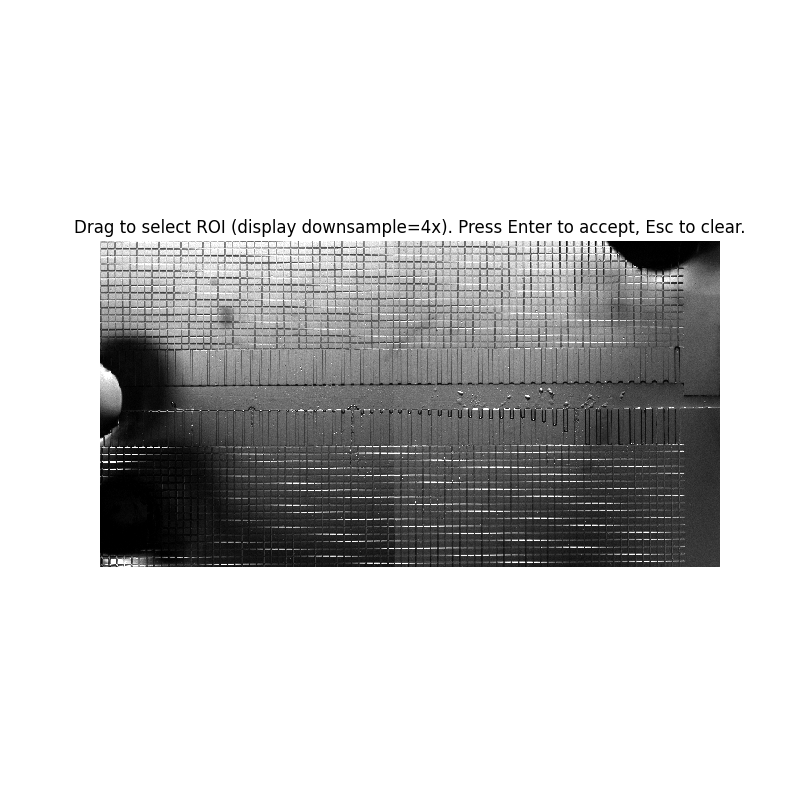

In [ ]:
roi_bac = ROI_selector_down(img,4)

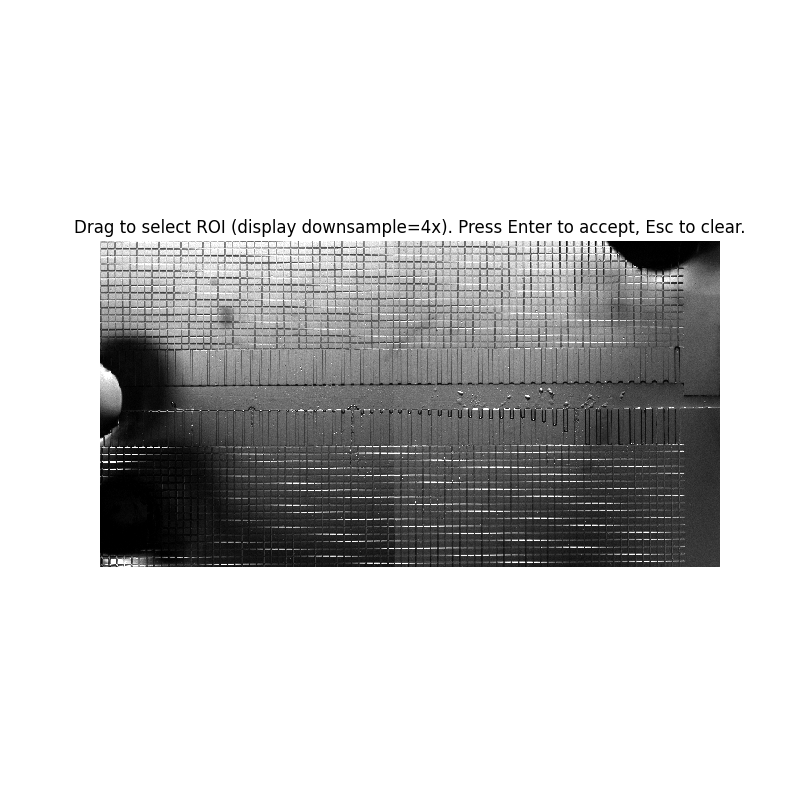

In [ ]:
roi_dic = ROI_selector_down(img,4)


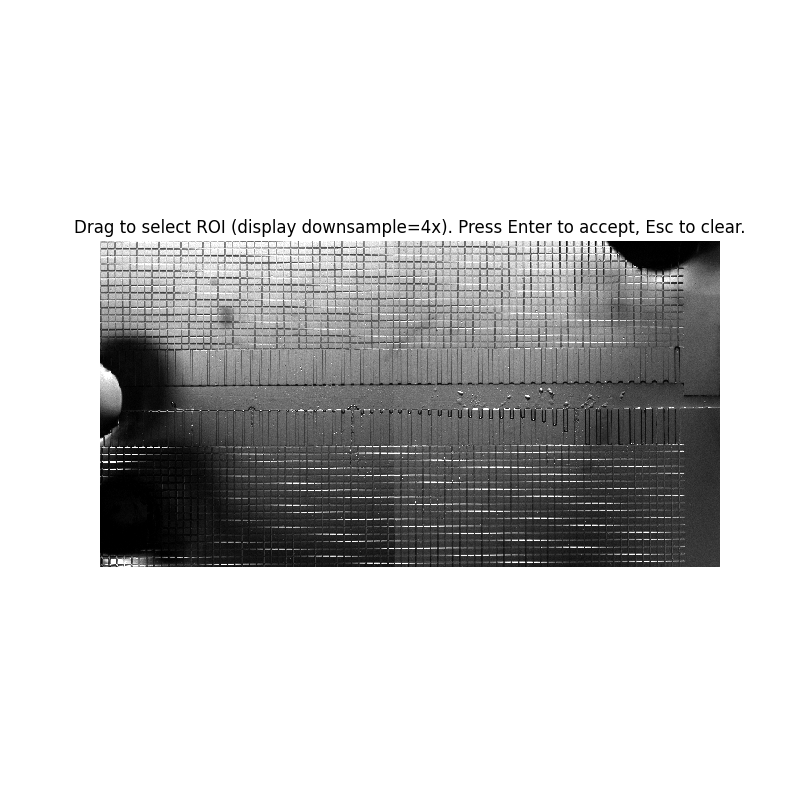

In [ ]:
roi_air = ROI_selector_down(img,4)


In [ ]:
import pandas as pd
import numpy as np
rois = [roi_bac,roi_dic,roi_air]
rois_names = ["roi_bac","roi_dic","roi_air"]




def compute_profiles_over_time_roi(
    czi,
    times,
    channels,
    rois,
    metrics=None
):
    """
    Returns DataFrame with columns:
      t, x, <metric1>, <metric2>, ...
    """
    if metrics is None:
        metrics = {"mean": profile_mean}

    frames = []

    for t in times:
        for channel in channels:
            for roi,roi_name in zip(rois,rois_names):
                img, _ = get_frame(czi, t, channel, roi=roi, gamma=1)
                row = {"t": t,"channel": channel,"roi_name":roi_name}

                for name, fn in metrics.items():
                    y = fn(img)
                    row[name] = y

                frames.append(row)

    return pd.DataFrame(frames)

In [36]:
from skimage import exposure
from skimage.feature import blob_dog, blob_log, blob_doh

def profile_mean(img):      return np.mean(img)
def count_cells(img):
    print(img.shape)
    img = img.astype(float)
    img = exposure.rescale_intensity(img, in_range='image', out_range=(0,1))
    img = (img - img.mean()) / img.std()

    image_gray = img

    blobs_doh = blob_doh(image_gray, min_sigma=5, max_sigma=20, num_sigma=10, threshold=0.2)
    return(len(blobs_doh))



times = list(range(0, dim_sizes["T"], 1))


metrics = {
    "mean": profile_mean,
    "cell_count": count_cells
}
channels = [0,1]

datatable = compute_profiles_over_time_roi(czi, times, channels, rois=rois, metrics=metrics)

(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)

In [37]:
df = datatable.copy()
times_tab = get_timestamps_by_T(czi, C=0, Z=0)
times_df = pd.DataFrame(times_tab, columns=["t", "timestr"])
df = df.merge(times_df, on="t", how="left")

df["datetime"] = pd.to_datetime(df["timestr"], utc=True)
t0 = df.loc[df["t"] == 0, "datetime"].iloc[0]

df["timedelta_from_0"] = df["datetime"] - t0
df["timedelta_hours"] = df["timedelta_from_0"].dt.total_seconds()/3600

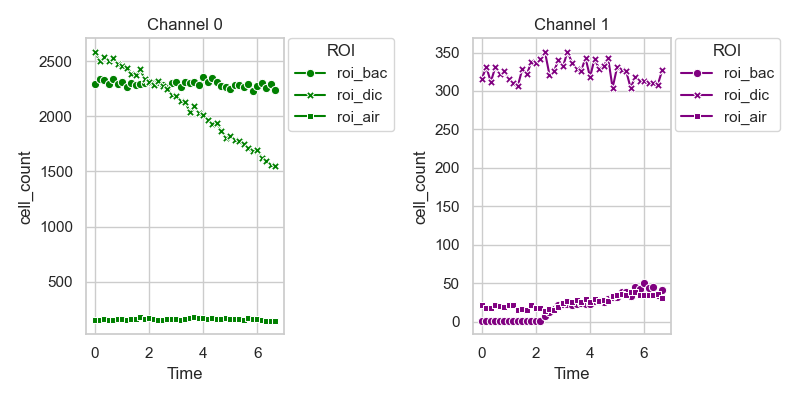

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(8,4), sharey=False)

colors = {0: "green", 1: "purple"}

for channel, ax in zip([0,1], axes):
    metric = "cell_count" if channel == 0 else "cell_count"
    sns.lineplot(
        data=df[df["channel"] == channel],
        x="timedelta_hours",
        y=metric,
        hue="roi_name",
        style="roi_name",        # different symbols per ROI
        markers=True,
        dashes=False,
        palette=[colors[channel]] * df["roi_name"].nunique(),
        ax=ax
    )
    
    ax.set_title(f"Channel {channel}")
    ax.set_xlabel("Time")
    ax.set_ylabel(metric)
    
    # move legend outside
    ax.legend(
        title="ROI",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

plt.tight_layout()
plt.show()

In [ ]:
"""
Detect rectangles in brightfield images (low-cost classic CV).
Output: list of detected rectangles with a quality score.

Dependencies:
  pip install opencv-python numpy

Usage:
  python detect_rectangles.py --image path/to/img.png
  # or import detect_rectangles in your own code and call detect_rectangles(...)
"""

from __future__ import annotations

import argparse
from dataclasses import dataclass
from typing import List, Tuple, Optional

import cv2
import numpy as np


@dataclass
class RectangleDetection:
    # 4 corner points in image coordinates (float32), clockwise order
    corners: np.ndarray  # shape (4, 2)
    # axis-aligned bbox (x, y, w, h) as ints
    bbox_xywh: Tuple[int, int, int, int]
    # 0..1 (higher is better)
    score: float
    # extra diagnostics if you want
    meta: dict


def _order_corners_clockwise(pts: np.ndarray) -> np.ndarray:
    """Order 4 points clockwise starting near top-left."""
    pts = np.asarray(pts, dtype=np.float32).reshape(4, 2)
    c = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    order = np.argsort(angles)
    pts = pts[order]
    # rotate so first is top-left-ish (min x+y)
    idx0 = np.argmin(pts[:, 0] + pts[:, 1])
    pts = np.roll(pts, -idx0, axis=0)
    return pts


def _angle_deviation_score(corners: np.ndarray) -> float:
    """
    Score based on how close the 4 internal angles are to 90 degrees.
    Returns 0..1.
    """
    pts = _order_corners_clockwise(corners)
    devs = []
    for i in range(4):
        p0 = pts[i]
        p1 = pts[(i - 1) % 4]
        p2 = pts[(i + 1) % 4]
        v1 = p1 - p0
        v2 = p2 - p0
        n1 = np.linalg.norm(v1) + 1e-9
        n2 = np.linalg.norm(v2) + 1e-9
        cosang = float(np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0))
        ang = np.degrees(np.arccos(cosang))
        devs.append(abs(ang - 90.0))
    mean_dev = float(np.mean(devs))
    # 0 dev -> 1.0 score, 25 deg dev -> ~0.0 score
    return float(np.clip(1.0 - (mean_dev / 25.0), 0.0, 1.0))


def _rectangularity_score(contour: np.ndarray) -> Tuple[float, np.ndarray, float]:
    """
    Rectangularity: area(contour) / area(minAreaRect)
    Also returns rect corners and rect area.
    """
    area = float(cv2.contourArea(contour))
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect).astype(np.float32)  # 4x2
    rect_area = float(rect[1][0] * rect[1][1])
    if rect_area <= 1e-9 or area <= 1e-9:
        return 0.0, box, rect_area
    rectangularity = float(np.clip(area / rect_area, 0.0, 1.0))
    return rectangularity, box, rect_area


def _edge_support_score(edges: np.ndarray, corners: np.ndarray, thickness: int = 2) -> float:
    """
    How much of the rectangle perimeter is supported by edge pixels.
    Draw perimeter mask and compute fraction of mask pixels that overlap edges.
    Returns 0..1.
    """
    h, w = edges.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    pts = _order_corners_clockwise(corners).astype(np.int32)
    cv2.polylines(mask, [pts], isClosed=True, color=255, thickness=thickness, lineType=cv2.LINE_AA)

    # binarize edges to {0,255}
    e = (edges > 0).astype(np.uint8) * 255
    overlap = cv2.bitwise_and(mask, e)

    denom = int(np.count_nonzero(mask))
    if denom == 0:
        return 0.0
    num = int(np.count_nonzero(overlap))
    return float(np.clip(num / denom, 0.0, 1.0))


def _nms_quads(dets: List[RectangleDetection], iou_thresh: float = 0.5) -> List[RectangleDetection]:
    """
    Simple NMS on axis-aligned bboxes using detection score.
    Keeps highest score when IoU exceeds threshold.
    """
    if not dets:
        return []

    boxes = np.array([d.bbox_xywh for d in dets], dtype=np.float32)  # x,y,w,h
    scores = np.array([d.score for d in dets], dtype=np.float32)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0:
        i = int(order[0])
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        inter_w = np.maximum(0.0, xx2 - xx1)
        inter_h = np.maximum(0.0, yy2 - yy1)
        inter = inter_w * inter_h

        area_i = (x2[i] - x1[i]) * (y2[i] - y1[i])
        area_o = (x2[order[1:]] - x1[order[1:]]) * (y2[order[1:]] - y1[order[1:]])
        union = area_i + area_o - inter + 1e-9
        iou = inter / union

        inds = np.where(iou <= iou_thresh)[0]
        order = order[inds + 1]

    return [dets[i] for i in keep]


def _normalize_brightfield(gray: np.ndarray, bg_kernel: int = 51) -> np.ndarray:
    """
    Background normalization: subtract a large blur (cheap 'flat-field-ish' correction),
    then CLAHE.
    """
    if bg_kernel % 2 == 0:
        bg_kernel += 1
    bg = cv2.GaussianBlur(gray, (bg_kernel, bg_kernel), 0)
    norm = cv2.subtract(gray, bg)
    norm = cv2.normalize(norm, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(norm)


def detect_rectangles(
    image_bgr_or_gray: np.ndarray,
    *,
    min_area: float = 200.0,
    max_area: Optional[float] = None,
    canny_sigma: float = 0.33,
    close_kernel: int = 3,
    approx_eps_factor: float = 0.02,
    angle_tol_deg: float = 15.0,
    nms_iou: float = 0.5,
    multi_pass: bool = True,
) -> List[RectangleDetection]:
    """
    Returns a list of RectangleDetection, sorted by score descending.

    Tuning guidance:
      - min_area: raise if you get many tiny false positives.
      - bg_kernel: in _normalize_brightfield, increase if illumination varies slowly.
      - angle_tol_deg: tighten (e.g. 10) for stricter rectangles.
      - multi_pass: True runs a few cheap variants to catch faint edges.
    """
    if image_bgr_or_gray.ndim == 3:
        gray = cv2.cvtColor(image_bgr_or_gray, cv2.COLOR_BGR2GRAY)
    else:
        gray = image_bgr_or_gray.copy()

    gray_n = _normalize_brightfield(gray)

    # Auto Canny thresholds from median
    med = float(np.median(gray_n))
    low = int(max(0, (1.0 - canny_sigma) * med))
    high = int(min(255, (1.0 + canny_sigma) * med))

    variants = []

    # Base edge map
    edges0 = cv2.Canny(gray_n, low, high, L2gradient=True)
    variants.append(("canny_base", edges0))

    if multi_pass:
        # Slightly more sensitive
        edges1 = cv2.Canny(gray_n, max(0, low // 2), min(255, int(high * 1.2)), L2gradient=True)
        variants.append(("canny_sensitive", edges1))
        # Adaptive threshold variant (sometimes good for faint outlines)
        thr = cv2.adaptiveThreshold(
            gray_n, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 2
        )
        edges2 = cv2.Canny(thr, 50, 150, L2gradient=True)
        variants.append(("adaptive+edges", edges2))

    k = max(1, int(close_kernel))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

    detections: List[RectangleDetection] = []

    for vname, edges in variants:
        # Close gaps
        edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

        # Find contours
        contours, _hier = cv2.findContours(edges_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            area = float(cv2.contourArea(cnt))
            if area < min_area:
                continue
            if max_area is not None and area > max_area:
                continue

            peri = float(cv2.arcLength(cnt, True))
            if peri <= 1e-9:
                continue

            eps = approx_eps_factor * peri
            poly = cv2.approxPolyDP(cnt, eps, True)

            if len(poly) != 4:
                continue
            if not cv2.isContourConvex(poly):
                continue

            poly_pts = poly.reshape(4, 2).astype(np.float32)

            # Angle check (quick reject)
            angle_score = _angle_deviation_score(poly_pts)
            # Convert tol to a reject threshold:
            # If tol is 15deg, then mean deviation > 15 => reject, roughly.
            # Our score maps 25deg dev to 0; so require score >= (1 - tol/25)
            min_angle_score = max(0.0, 1.0 - (angle_tol_deg / 25.0))
            if angle_score < min_angle_score:
                continue

            rectangularity, rect_box, rect_area = _rectangularity_score(cnt)
            if rectangularity < 0.6:
                continue

            edge_support = _edge_support_score(edges_closed, rect_box, thickness=2)

            # Combine into final quality score (0..1)
            # You can re-weight depending on what "quality" means for your images.
            score = float(
                np.clip(
                    0.45 * rectangularity + 0.35 * edge_support + 0.20 * angle_score,
                    0.0,
                    1.0,
                )
            )

            # Axis-aligned bbox for NMS
            x, y, w, h = cv2.boundingRect(rect_box.astype(np.int32))

            detections.append(
                RectangleDetection(
                    corners=_order_corners_clockwise(rect_box),
                    bbox_xywh=(int(x), int(y), int(w), int(h)),
                    score=score,
                    meta={
                        "variant": vname,
                        "contour_area": area,
                        "rect_area": rect_area,
                        "rectangularity": rectangularity,
                        "edge_support": edge_support,
                        "angle_score": angle_score,
                    },
                )
            )

    # NMS & sort
    detections = _nms_quads(detections, iou_thresh=nms_iou)
    detections.sort(key=lambda d: d.score, reverse=True)
    return detections


def _draw_detections(image: np.ndarray, dets: List[RectangleDetection]) -> np.ndarray:
    """Convenience visualization (optional)."""
    if image.ndim == 2:
        vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        vis = image.copy()

    for d in dets:
        pts = d.corners.astype(np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 2, lineType=cv2.LINE_AA)
        x, y, w, h = d.bbox_xywh
        cv2.putText(
            vis,
            f"{d.score:.2f}",
            (x, max(0, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )
    return vis




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4499.0].


Detected 1124 rectangles

000 | score=0.815 | bbox=(2880, 4368, 87, 86) | rectangularity=0.964 | edge_support=0.534 | angle=0.972
001 | score=0.814 | bbox=(5670, 1115, 86, 86) | rectangularity=0.944 | edge_support=0.589 | angle=0.914
002 | score=0.814 | bbox=(5470, 1320, 87, 85) | rectangularity=0.905 | edge_support=0.647 | angle=0.901
003 | score=0.812 | bbox=(2170, 3968, 86, 86) | rectangularity=0.978 | edge_support=0.506 | angle=0.972
004 | score=0.812 | bbox=(6279, 1315, 86, 85) | rectangularity=0.951 | edge_support=0.557 | angle=0.943
005 | score=0.807 | bbox=(5160, 612, 86, 83) | rectangularity=0.937 | edge_support=0.573 | angle=0.925
006 | score=0.807 | bbox=(5985, 2937, 91, 83) | rectangularity=0.943 | edge_support=0.579 | angle=0.896
007 | score=0.805 | bbox=(4854, 210, 86, 80) | rectangularity=0.945 | edge_support=0.532 | angle=0.969
008 | score=0.802 | bbox=(4754, 513, 87, 82) | rectangularity=0.936 | edge_support=0.548 | angle=0.944
009 | score=0.801 | bbox=(4060, 12, 68, 7

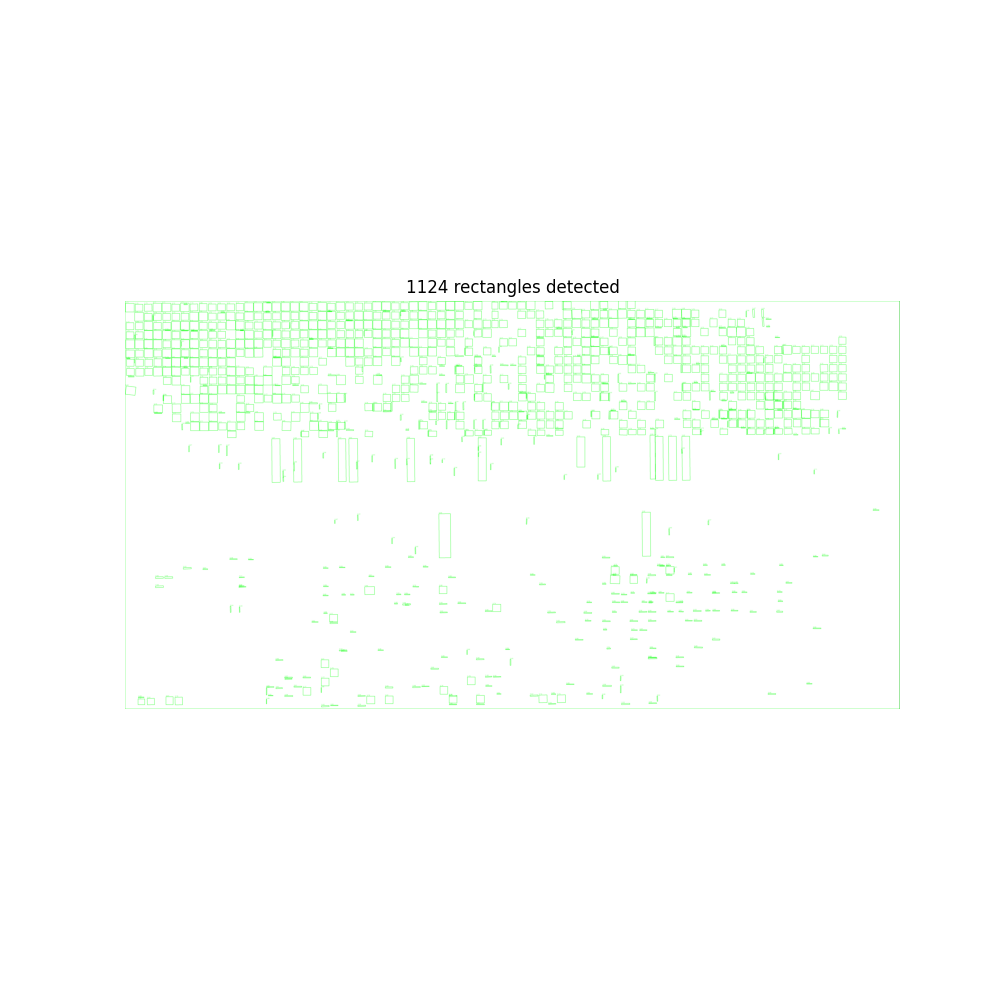

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIG ---
image_path = "your_image.png"   # change to your image
min_area = 200                  # adjust if you detect tiny noise
max_area = None


# --- RUN DETECTION ---
detections = detect_rectangles(
    img,
    min_area=min_area,
    max_area=max_area
)

# --- PRINT RESULTS ---
print(f"Detected {len(detections)} rectangles\n")

for i, d in enumerate(detections):
    print(
        f"{i:03d} | score={d.score:.3f} | bbox={d.bbox_xywh} | "
        f"rectangularity={d.meta['rectangularity']:.3f} | "
        f"edge_support={d.meta['edge_support']:.3f} | "
        f"angle={d.meta['angle_score']:.3f}"
    )

# --- VISUALIZE ---
vis = _draw_detections(img, detections)

plt.figure(figsize=(10,10))
plt.imshow(vis)
plt.title(f"{len(detections)} rectangles detected")
plt.axis("off")
plt.show()

In [ ]:
times

[(0,
  datetime.datetime(2026, 1, 12, 12, 45, 19, 993613, tzinfo=datetime.timezone.utc)),
 (1,
  datetime.datetime(2026, 1, 12, 12, 55, 18, 532947, tzinfo=datetime.timezone.utc)),
 (2,
  datetime.datetime(2026, 1, 12, 13, 5, 18, 518471, tzinfo=datetime.timezone.utc)),
 (3,
  datetime.datetime(2026, 1, 12, 13, 15, 18, 551826, tzinfo=datetime.timezone.utc)),
 (4,
  datetime.datetime(2026, 1, 12, 13, 25, 18, 516089, tzinfo=datetime.timezone.utc)),
 (5,
  datetime.datetime(2026, 1, 12, 13, 35, 18, 556246, tzinfo=datetime.timezone.utc)),
 (6,
  datetime.datetime(2026, 1, 12, 13, 45, 18, 552209, tzinfo=datetime.timezone.utc)),
 (7,
  datetime.datetime(2026, 1, 12, 13, 55, 18, 554697, tzinfo=datetime.timezone.utc)),
 (8,
  datetime.datetime(2026, 1, 12, 14, 5, 18, 565651, tzinfo=datetime.timezone.utc)),
 (9,
  datetime.datetime(2026, 1, 12, 14, 15, 18, 567465, tzinfo=datetime.timezone.utc)),
 (10,
  datetime.datetime(2026, 1, 12, 14, 25, 18, 517647, tzinfo=datetime.timezone.utc)),
 (11,
  dat

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_15763/1358120255.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(np_img_u8, mode=mode)


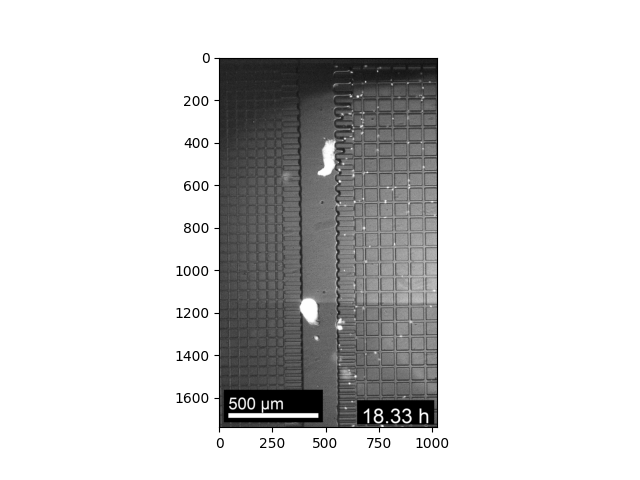

In [ ]:
frame = make_annotated(
    img_disp,
    time,
    times,
    pixel_size["X"],
    resize_width= 1024,
    mode = "L"
)
fig,ax = plt.subplots()
ax.imshow(frame,cmap="gray")

In [ ]:
_, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi)

ch_magenta = norm(ch_magenta)

rgb_magenta = mcherry(ch_magenta)[..., :3]


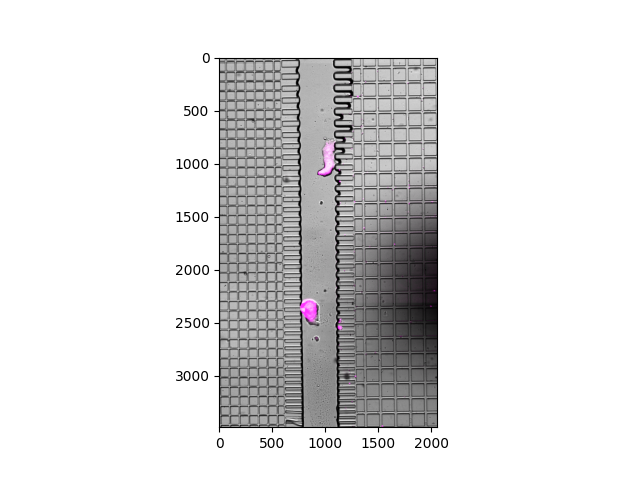

In [ ]:
stretch_min = 96
stretch_max = 99.5
_, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi,    stretch_min = stretch_min, stretch_max = stretch_max)
_, ch_gray    = get_frame(czi, time, 2, gamma=1, roi=roi)

ch_magenta = norm(ch_magenta)
ch_gray    = norm(ch_gray)

rgb_magenta = mcherry(ch_magenta)[..., :3]
rgb_gray    = gray_cmap(ch_gray)[..., :3]
merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)
fig,ax = plt.subplots()
ax.imshow(merged)

In [ ]:
# ---- your settings ----
scale_factor = 6000.0   # 10x faster
fps = 10
output = "/Users/bisot/Documents/PostDoc2/test_data/movie.mp4"

# Parse timestamps
frame_idxs = [i for i, _ in times]
ts = [s for _, s in times]

# Compute real deltas (seconds)
real_deltas = [None]
for k in range(1, len(ts)):
    dt = max((ts[k] - ts[k-1]).total_seconds(), 0.0)
    real_deltas.append(dt)

positive = [d for d in real_deltas[1:] if d and d > 0]
baseline = median(positive) if positive else 1.0
real_deltas[0] = baseline
if len(real_deltas) > 1:
    real_deltas[-1] = real_deltas[-2] if real_deltas[-2] is not None else baseline

video_durations = [clamp(float(d) / scale_factor, 0.0, 1e12) for d in real_deltas]

# Build clips
clips = []
for (frame_i, (time_i, _)), dur in zip(enumerate(times), video_durations):
    # NOTE: you currently loop "for time,_ in times:" where time is frame index.
    time = time_i

    _, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi, stretch_min = stretch_min, stretch_max = stretch_max)
    _, ch_gray    = get_frame(czi, time, 2, gamma=1, roi=roi)

    ch_magenta = norm(ch_magenta)
    ch_gray    = norm(ch_gray)

    rgb_magenta = mcherry(ch_magenta)[..., :3]
    rgb_gray    = gray_cmap(ch_gray)[..., :3]
    merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)

    frame = make_annotated(
        merged,
        time,
        times,          # pass indices (or your original list, up to you)
        pixel_size["X"],
        resize_width=1024,
        mode="RGB",
    )

    # Ensure uint8 for MoviePy
    if frame.dtype != np.uint8:
        frame_u8 = (np.clip(frame, 0, 1) * 255).astype(np.uint8) if frame.max() <= 1.0 else frame.astype(np.uint8)
    else:
        frame_u8 = frame

    clips.append(ImageClip(frame_u8, duration=dur))

final = concatenate_videoclips(clips, method="compose")
final.write_videofile(
    output,
    fps=fps,
    codec="libx264",
    audio=False,
    ffmpeg_params=[
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-profile:v", "baseline",
        "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
    ],
)

print("✅ Done:", output)


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_15763/1358120255.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(np_img_u8, mode=mode)


MoviePy - Building video /Users/bisot/Documents/PostDoc2/test_data/movie.mp4.
MoviePy - Writing video /Users/bisot/Documents/PostDoc2/test_data/movie.mp4



MoviePy - Done !
MoviePy - video ready /Users/bisot/Documents/PostDoc2/test_data/movie.mp4
✅ Done: /Users/bisot/Documents/PostDoc2/test_data/movie.mp4
